In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

In [2]:
load_dotenv(override=True)

model = ChatOpenAI()

In [14]:
class BlogState(TypedDict):

    title: str
    outline: str
    content: str
    evaluate: float

In [5]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [6]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content

    return state

In [26]:
def evaluate_blog(state: BlogState) -> BlogState:

    outline = state['outline']
    content = state['content']

    prompt = """Evaluate the content - {content} based on the following outline - {outline} 
    And give a score of 0 to 10 based on how well the content adheres to the outline and how good the content is overall.

    Output FORMAT :
        {score}

    """

    score = model.invoke(prompt).content

    state['evaluate'] = float(score)

    return state

In [ ]:
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()


In [18]:
intial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

print(final_state)

KeyError: 'content'

In [12]:
print(final_state['outline'])

I. Introduction
    A. Definition of artificial intelligence (AI)
    B. Overview of the current landscape of AI in India
    C. Thesis statement: The rise of AI in India is transforming industries and revolutionizing the way business is conducted

II. Historical background of AI in India
    A. Early developments in AI research in India
    B. Adoption of AI technologies in Indian industries
    C. Government initiatives to promote AI innovation

III. Current state of AI in India
    A. Growth of AI startups in India
    B. AI usage in various industries such as healthcare, finance, and education
    C. Challenges faced by AI adoption in India

IV. Impact of AI on the Indian economy
    A. Job creation and displacement due to AI
    B. Increased efficiency and productivity in businesses
    C. Potential economic benefits of AI adoption in India

V. Government policies and regulations related to AI in India
    A. National AI strategy and initiatives
    B. Data privacy and security re

In [13]:
print(final_state['content'])

Artificial intelligence (AI) is the ability of a machine or computer system to perform tasks that typically require human intelligence, such as visual perception, speech recognition, decision-making, and language translation. In recent years, AI has been gaining traction in India and is transforming industries and revolutionizing the way business is conducted. This blog will delve into the rise of AI in India, exploring its historical background, current state, impact on the economy, government policies and regulations, future outlook, and successful case studies.

Historical background of AI in India:
India has a rich history of research and development in AI dating back to the 1980s. Indian universities and research institutions have made significant contributions to the field of AI, with notable achievements in areas such as natural language processing, computer vision, and robotics. Over the years, AI technologies have been adopted by Indian industries, including healthcare, financ

In [27]:
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)
graph.add_node('evaluate_blog', evaluate_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', 'evaluate_blog')
graph.add_edge('evaluate_blog', END)

workflow = graph.compile()


In [28]:
initial_state = {'title': 'Rise of AI in India'}

workflow.invoke(intial_state)

ValueError: could not convert string to float: "I'm happy to help evaluate the content, but could you please provide me with the content and outline that you would like me to assess?"

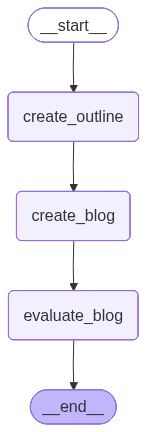

In [21]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())